<a href="https://colab.research.google.com/github/JayDaslani/Fraud-detection-project/blob/main/Fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ============================================
##Fraud Detection — Industry Project
## Author: Dasalani Jay
## Date: March 2025
##Goal: Predict Transaction is fraud or not
## ============================================

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("All libraryies are successfully loaded !")

All libraryies are successfully loaded !


In [2]:
df = pd.read_csv('/content/creditcard.csv')

In [3]:
print('train_dataset shape :',df.shape)

train_dataset shape : (41683, 31)


In [4]:
print('Target columns (Class):')
print(df['Class'].value_counts())

Target columns (Class):
Class
0.000    41574
1.000      108
Name: count, dtype: int64


In [5]:
print(f"Fraud rate : {df['Class'].mean()*100:.2f}%")

Fraud rate : 0.26%


##First look at data

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0.000
1,0,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0.000
2,1,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0.000
3,1,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0.000
4,2,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0.000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41683 entries, 0 to 41682
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    41683 non-null  int64  
 1   V1      41683 non-null  float64
 2   V2      41683 non-null  float64
 3   V3      41682 non-null  float64
 4   V4      41682 non-null  float64
 5   V5      41682 non-null  float64
 6   V6      41682 non-null  float64
 7   V7      41682 non-null  float64
 8   V8      41682 non-null  float64
 9   V9      41682 non-null  float64
 10  V10     41682 non-null  float64
 11  V11     41682 non-null  float64
 12  V12     41682 non-null  float64
 13  V13     41682 non-null  float64
 14  V14     41682 non-null  float64
 15  V15     41682 non-null  float64
 16  V16     41682 non-null  float64
 17  V17     41682 non-null  float64
 18  V18     41682 non-null  float64
 19  V19     41682 non-null  float64
 20  V20     41682 non-null  float64
 21  V21     41682 non-null  float64
 22

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,41683.000,41683.000,41683.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000,41682.000
mean,26208.346,-0.222,0.035,0.712,0.187,-0.235,0.100,-0.112,0.045,0.194,-0.067,0.411,-0.435,0.227,0.224,0.103,-0.003,0.146,-0.091,-0.032,0.047,-0.028,-0.111,-0.040,0.007,0.136,0.023,0.008,0.005,89.104,0.003
std,12721.515,1.855,1.600,1.490,1.400,1.387,1.310,1.238,1.209,1.220,1.119,1.125,1.367,1.139,1.124,0.955,0.924,1.028,0.855,0.816,0.698,0.744,0.638,0.565,0.593,0.437,0.504,0.388,0.342,237.164,0.051
min,0.000,-56.408,-72.716,-31.104,-5.173,-42.148,-26.161,-26.548,-41.485,-7.175,-14.167,-4.050,-17.769,-3.836,-19.214,-4.153,-12.227,-18.587,-8.061,-4.933,-13.695,-20.262,-8.594,-26.751,-2.837,-7.496,-1.439,-8.568,-9.618,0.000,0.000
25%,16853.000,-0.974,-0.533,0.230,-0.719,-0.842,-0.638,-0.598,-0.151,-0.569,-0.548,-0.406,-1.235,-0.540,-0.269,-0.457,-0.493,-0.348,-0.567,-0.525,-0.164,-0.235,-0.533,-0.179,-0.325,-0.128,-0.330,-0.063,-0.007,7.500,0.000
50%,31305.000,-0.240,0.094,0.811,0.185,-0.272,-0.156,-0.073,0.050,0.071,-0.128,0.382,-0.095,0.157,0.188,0.219,0.061,0.083,-0.074,-0.033,-0.022,-0.075,-0.086,-0.051,0.061,0.176,-0.065,0.009,0.022,24.000,0.000
75%,36289.000,1.159,0.740,1.443,1.069,0.293,0.486,0.432,0.319,0.907,0.383,1.201,0.505,0.959,0.779,0.781,0.557,0.571,0.403,0.476,0.169,0.103,0.301,0.077,0.400,0.421,0.304,0.085,0.076,80.000,0.000
max,40784.000,1.960,16.713,4.102,16.491,34.802,22.529,36.677,20.007,10.393,12.702,12.019,4.846,4.465,7.692,5.785,6.099,9.254,4.296,4.555,17.282,22.615,5.806,17.298,4.014,5.525,3.517,11.136,33.848,7879.420,1.000


In [9]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        1
V4        1
V5        1
V6        1
V7        1
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [10]:
missing_rows = df[df.isnull().any(axis=1)]
print("Missing rows : ",len(missing_rows))
print(missing_rows)

Missing rows :  1
        Time     V1     V2  V3  V4  V5  V6  V7  V8  V9  V10  V11  V12  V13  \
41682  40784 -0.621 -0.734 NaN NaN NaN NaN NaN NaN NaN  NaN  NaN  NaN  NaN   

       V14  V15  V16  V17  V18  V19  V20  V21  V22  V23  V24  V25  V26  V27  \
41682  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

       V28  Amount  Class  
41682  NaN     NaN    NaN  


In [11]:
df = df.dropna()
df.shape


(41682, 31)

In [12]:
df['Class'] = df['Class'].astype(int)
print("Class dtype : ", df['Class'].dtype)

Class dtype :  int64


In [13]:
print("Normal Transaction ")
print(df[df['Class']==0].describe())


Normal Transaction 
           Time        V1        V2        V3        V4        V5        V6  \
count 41574.000 41574.000 41574.000 41574.000 41574.000 41574.000 41574.000   
mean  26220.447    -0.204     0.021     0.741     0.172    -0.222     0.106   
std   12723.790     1.758     1.558     1.287     1.364     1.320     1.303   
min       0.000   -56.408   -72.716   -27.747    -5.173   -42.148   -26.161   
25%   16914.500    -0.969    -0.535     0.236    -0.721    -0.839    -0.634   
50%   31323.500    -0.236     0.091     0.815     0.180    -0.271    -0.154   
75%   36301.000     1.160     0.736     1.445     1.062     0.294     0.488   
max   40783.000     1.960    14.846     4.102    16.491    34.802    22.529   

             V7        V8        V9       V10       V11       V12       V13  \
count 41574.000 41574.000 41574.000 41574.000 41574.000 41574.000 41574.000   
mean     -0.093     0.035     0.202    -0.050     0.398    -0.415     0.227   
std       1.126     1.155     1

In [14]:
print("Fraud Transaction")
print(df[df['Class']==1].describe())

Fraud Transaction
           Time      V1      V2      V3      V4      V5      V6      V7  \
count   108.000 108.000 108.000 108.000 108.000 108.000 108.000 108.000   
mean  21414.991  -7.455   5.595 -10.624   5.850  -5.116  -2.288  -7.382   
std   10822.969   9.305   4.826   9.583   2.858   6.994   1.630   7.189   
min     406.000 -30.552  -5.198 -31.104   0.817 -22.106  -4.978 -21.923   
25%   11121.250 -15.303   2.226 -19.955   3.771  -9.185  -3.358 -15.386   
50%   21232.500  -3.131   4.113  -5.923   6.028  -2.451  -2.328  -4.631   
75%   28947.750  -0.186   8.671  -3.226   6.669   0.030  -1.215  -1.574   
max   40742.000   1.234  16.713   2.041  11.928   5.269   3.628   5.431   

           V8      V9     V10     V11     V12     V13     V14     V15     V16  \
count 108.000 108.000 108.000 108.000 108.000 108.000 108.000 108.000 108.000   
mean    3.691  -2.905  -6.511   5.398  -8.130   0.346  -8.295  -0.007  -4.722   
std     6.140   2.264   4.126   3.071   4.516   0.926   4.457  

In [15]:
df['Hour'] = (df['Time'] % 3600) // 3600

## ============================================
## Exploratory Data Analysis (EDA)
## ============================================
## Goal: Keep Business insights

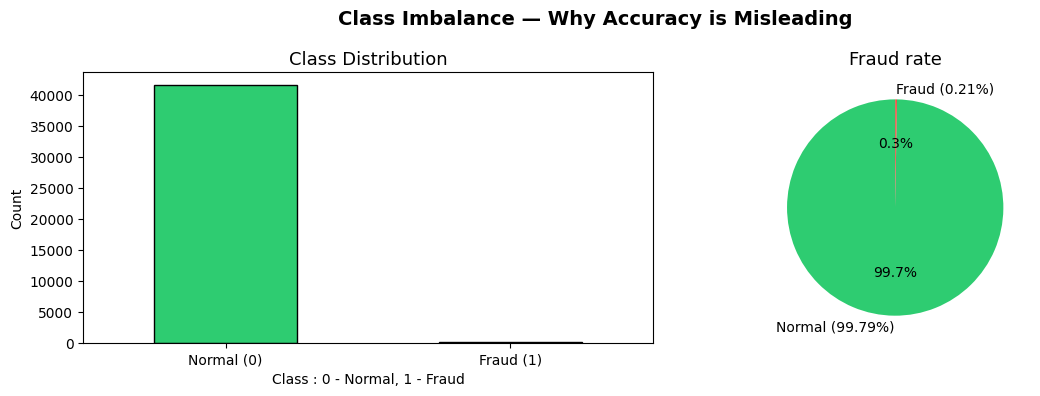

Bussiness Insights


In [16]:
fig, axes = plt.subplots(1, 2 , figsize=(12,4))

df['Class'].value_counts().plot(
    kind='bar',
    ax = axes[0],
    color=['#2ecc71','#e74c3c'],
    edgecolor='black'
)
axes[0].set_title('Class Distribution',fontsize=13)
axes[0].set_xlabel('Class : 0 - Normal, 1 - Fraud')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)

sizes = df['Class'].value_counts()
axes[1].pie(
    sizes,
    labels=['Normal (99.79%)', 'Fraud (0.21%)'],
    colors=['#2ecc71','#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Fraud rate',fontsize=13)

plt.suptitle('Class Imbalance — Why Accuracy is Misleading',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Bussiness Insights")

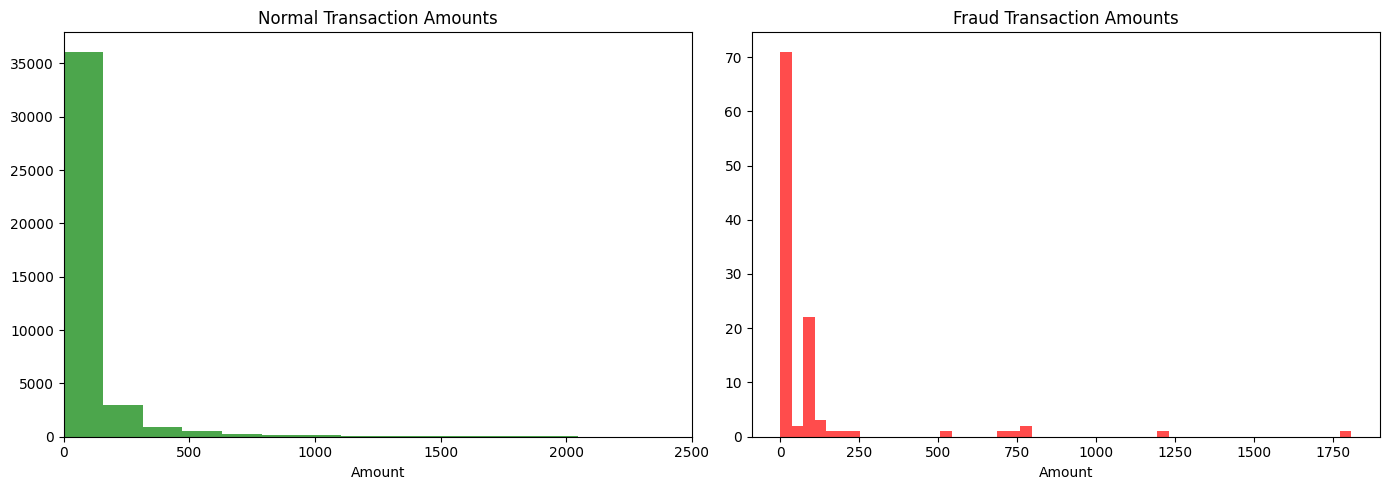

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal transactions
axes[0].hist(df[df['Class']==0]['Amount'],
             bins=50, color='green', alpha=0.7)
axes[0].set_title('Normal Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[0].set_xlim(0, 2500)

# Fraud transactions
axes[1].hist(df[df['Class']==1]['Amount'],
             bins=50, color='red', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()

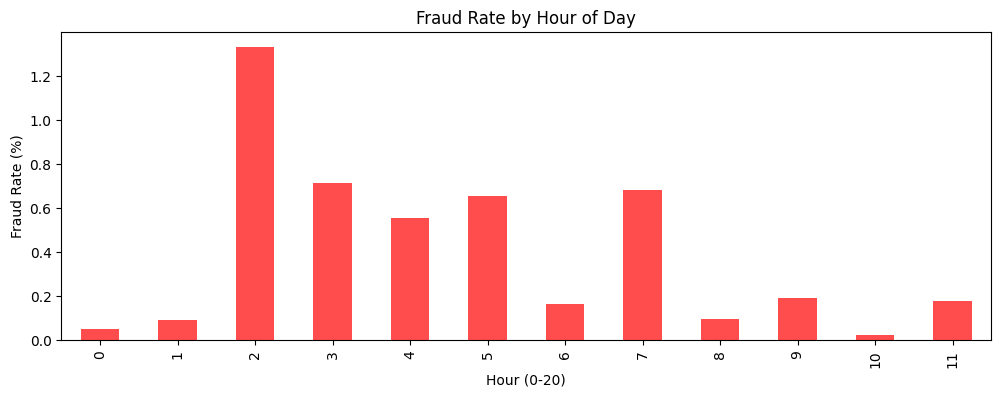

Highest fraud hour: 2
Lowest fraud hour: 10


In [18]:
df['Hour'] = (df['Time'] // 3600).astype(int)

fraud_by_hour = df.groupby('Hour')['Class'].mean() * 100

plt.figure(figsize=(12, 4))
fraud_by_hour.plot(kind='bar', color='red', alpha=0.7)
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour (0-20)')
plt.ylabel('Fraud Rate (%)')
plt.show()

print("Highest fraud hour:",
      fraud_by_hour.idxmax())
print("Lowest fraud hour:",
      fraud_by_hour.idxmin())

In [19]:
# Sahi formula:
df['Hour'] = (df['Time'] // 3600).astype(int)

print(df['Hour'].unique())
print(df['Hour'].value_counts())

[ 0  1  2  3  4  5  6  7  8  9 10 11]
Hour
10    8288
9     7878
8     5179
0     3963
7     3368
11    2798
1     2217
6     1831
3     1821
5     1681
2     1576
4     1082
Name: count, dtype: int64


In [20]:
correlation = df.corr()['Class'].drop('Class')
correlations = correlation.abs().sort_values(ascending=False)
print("Top 10 features correlated with fraud:")
print(correlations.head(10))

Top 10 features correlated with fraud:
V3    0.388
V14   0.386
V17   0.382
V7    0.299
V10   0.294
V12   0.287
V16   0.260
V11   0.226
V4    0.206
V1    0.199
Name: Class, dtype: float64


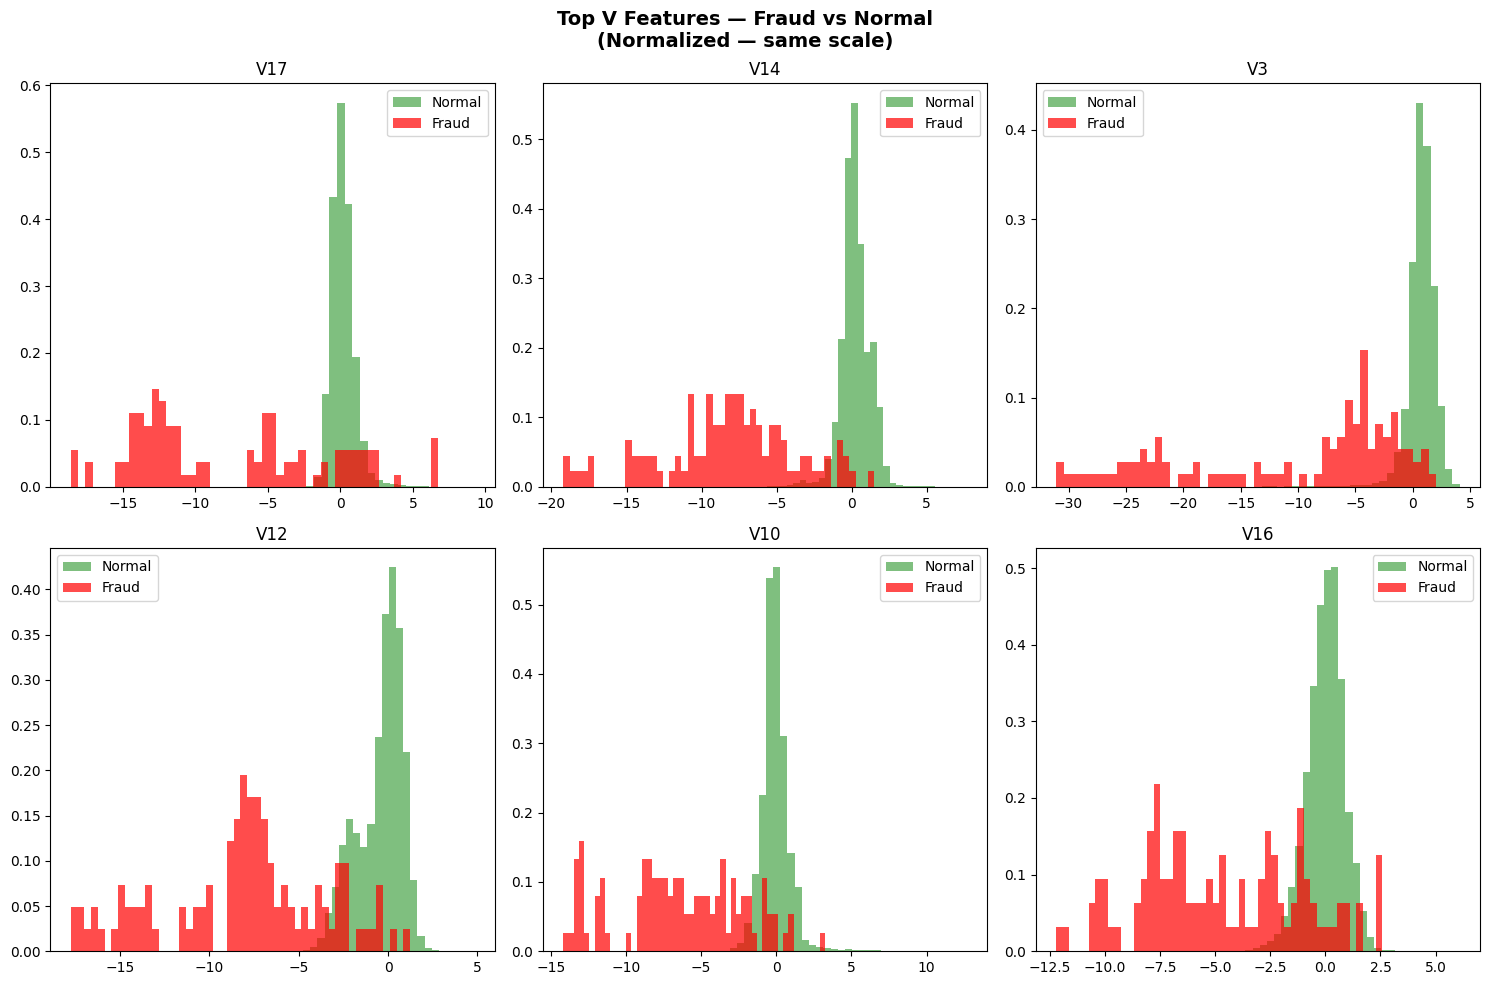

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

top_features = ['V17', 'V14', 'V3',
                'V12', 'V10', 'V16']

for i, feat in enumerate(top_features):
    # Normal
    axes[i].hist(
        df[df['Class']==0][feat],
        bins=50, alpha=0.5,
        color='green', label='Normal',
        density=True  # ← Percentage mein
    )
    # Fraud
    axes[i].hist(
        df[df['Class']==1][feat],
        bins=50, alpha=0.7,
        color='red', label='Fraud',
        density=True  # ← Percentage mein
    )
    axes[i].set_title(f'{feat}')
    axes[i].legend()

plt.suptitle(
    'Top V Features — Fraud vs Normal\n'
    '(Normalized — same scale)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Feature Engineering

In [22]:
df['Amount_log'] = np.log1p(df['Amount'])

print("Before Transform")
print(f"Skewness: {df['Amount'].skew():.2f}")
print("\nAfter transform:")
print(f"Skewness: {df['Amount_log'].skew():.2f}")

Before Transform
Skewness: 10.13

After transform:
Skewness: 0.11


In [23]:
df['Is_night'] = df['Hour'].apply(lambda x : 1 if (x <= 6 or x>=20) else 0)

In [24]:
print("\nIs_Night fraud rate:")
print(df.groupby('Is_night')['Class'].mean()*100)


Is_Night fraud rate:
Is_night
0   0.182
1   0.409
Name: Class, dtype: float64


In [25]:
df['Amount_Category'] = pd.cut(df['Amount'],bins=[0,10,50,200,1000,20000],labels=['Micro','Small','Medium','Large','Very Large'])
print("\nFraud rate by Amount Category:")
print(df.groupby('Amount_Category', observed=True)['Class'].mean()*100)


Fraud rate by Amount Category:
Amount_Category
Micro        0.454
Small        0.064
Medium       0.286
Large        0.162
Very Large   0.460
Name: Class, dtype: float64


In [26]:
df['V17_V14_Combined'] = df['V17'] * df['V14']
df['V3_V10_Combined']  = df['V3']  * df['V10']

# Verify
print("V17_V14_Combined correlation:")
print(df['V17_V14_Combined'].corr(df['Class']))

print("\nV3_V10_Combined correlation:")
print(df['V3_V10_Combined'].corr(df['Class']))

V17_V14_Combined correlation:
0.5379609379345955

V3_V10_Combined correlation:
0.5977334161302289


In [27]:
drop_cols = ['Amount','Time']
df = df.drop(drop_cols, axis=1)
df = pd.get_dummies(df, columns=['Amount_Category'], drop_first=True)
print(f"Final shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Final shape: (41682, 38)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Hour', 'Amount_log', 'Is_night', 'V17_V14_Combined', 'V3_V10_Combined', 'Amount_Category_Small', 'Amount_Category_Medium', 'Amount_Category_Large', 'Amount_Category_Very Large']


In [28]:
df.to_csv('fraud_features.csv', index=False)
print("✅ Saved!")

✅ Saved!


In [29]:
print(df.shape)
print(df.duplicated().sum())

(41682, 38)
701


In [30]:
df = df.drop_duplicates()
print(f"After dedup: {df.shape}")

After dedup: (40981, 38)


In [31]:
# Class distribution dekho
print(df['Class'].value_counts())
print(f"Fraud rate: {df['Class'].mean()*100:.3f}%")

# Original tha:
# Normal: 116,697
# Fraud : 244

Class
0    40873
1      108
Name: count, dtype: int64
Fraud rate: 0.264%


In [32]:
# ============================================
# FRAUD DETECTION — Fresh Start
# ============================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load
df = pd.read_csv('creditcard.csv')
print(f"1. Loaded: {df.shape}")

# Clean
df = df.dropna()
df['Class'] = df['Class'].astype(int)
print(f"2. Cleaned: {df.shape}")

# Features
df['Hour'] = (df['Time'] // 3600).astype(int)
df['Amount_Log'] = np.log1p(df['Amount'])
df['Is_Night'] = df['Hour'].apply(
    lambda x: 1 if (x <= 6 or x >= 20) else 0)
df['Amount_Category'] = pd.cut(
    df['Amount'],
    bins=[0, 10, 50, 200, 1000, 20000],
    labels=['Micro','Small','Medium',
            'Large','Very_Large']
)
df['V17_V14_Combined'] = df['V17'] * df['V14']
df['V3_V10_Combined']  = df['V3']  * df['V10']

# Drop
df = df.drop(columns=['Amount', 'Time'])

# Dummies
df = pd.get_dummies(
    df, columns=['Amount_Category'],
    drop_first=True
)

print(f"3. Final: {df.shape}")
print(f"4. Fraud rate: {df['Class'].mean()*100:.3f}%")
print(f"5. Duplicates: {df.duplicated().sum()}")

1. Loaded: (41683, 31)
2. Cleaned: (41682, 31)
3. Final: (41682, 38)
4. Fraud rate: 0.259%
5. Duplicates: 701


In [33]:
# Duplicates remove karo
df = df.drop_duplicates()
print(f"After dedup: {df.shape}")
print(f"Fraud cases: {df['Class'].sum()}")
print(f"Fraud rate : {df['Class'].mean()*100:.3f}%")

After dedup: (40981, 38)
Fraud cases: 108
Fraud rate : 0.264%
